# Tutorial: Generative Model Learning of Shapes

## Introduction to Generative Models

This tutorial demonstrates how learn the distribution of complex objects using generative models. The metholology is inspired from these [two](https://arxiv.org/abs/2308.03662) [papers](https://arxiv.org/abs/1810.01118).

We have a probability distribution of a set of ellipsis, each centered in (0,0), and we want to construct a surrogate probability distribution using generative models.


Let's first write the code for data generation.

In [1]:
import torch
from pina import LabelTensor
n=600
density=100
torch.manual_seed(42)
def generate_data(n,density=1000):

  theta = 2 * torch.pi * torch.linspace(0,1,density)
  x = torch.cos(theta)
  y = torch.sin(theta)
  data_ref=torch.concatenate((x.reshape(-1,1),y.reshape(-1,1)),axis=1)
  data=torch.zeros((n,density,2))

  for i in range(n):
      A=-0.4+0.8*torch.rand(2,2)
      A=A/torch.linalg.norm(A)
      A=A+torch.eye(2)
      A=2*A/torch.linalg.norm(A)
      data[i]=data_ref@A

  data=data.reshape(n,-1)
  return data

data=generate_data(n,density)


Let's plot an ellipse just to check that everything is going smoothly.

[(-2.0, 2.0), (-2.0, 2.0)]

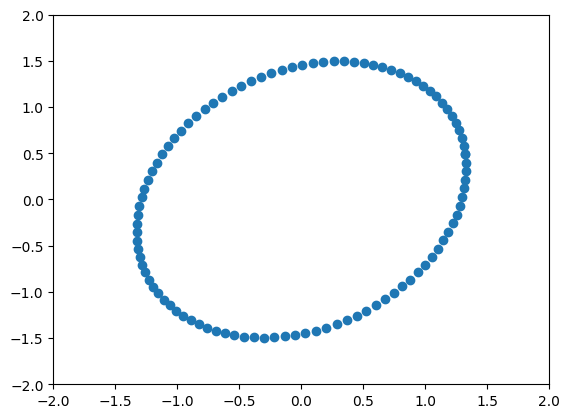

In [2]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ellipse=data.reshape(-1,density,2)[0]
ax.scatter(ellipse[:,0],ellipse[:,1])
ax.set(xlim=(-2,2), ylim=(-2, 2))



Now we are ready to define our generative model, which is composed by an AutoEncoder only.
First we define the AutoEncoder. As all the ellipsis in the dataset have barycenter as the origin, we impose this information in the AutoEncoder, we adopt POD and BatchNorm for further regularization. We add a sinkhorn regularization to the loss function, so that we are able to directly sample from the latent space in order to get good representations.

In [ ]:


import torch
from torch import nn
from pina.model.block import PODBlock

def barycenter_projector(x):
    x=x.reshape(-1,density,2)
    tmp=(x-torch.mean(x,axis=1).reshape(-1,1,2))
    return tmp.reshape(-1,2*density)

class LBR(torch.nn.Module):
    def __init__(self,input_size,output_size,final=False,drop_prob=0.1):
        super().__init__()
        self.lin=nn.Linear(input_size,output_size)
        self.relu=nn.ReLU()
        self.bn=nn.BatchNorm1d(output_size)
        self.dropout=nn.Dropout(drop_prob)

    def forward(self,input):
        tmp=self.dropout(self.bn(self.relu(self.lin(input))))
        return tmp

class GenEncoder(torch.nn.Module):
    def __init__(self,input_size,latent_size,hidden_size=500,num_layers=5,drop_prob=0.1):
        super().__init__()
        self.layers = []
        self.layers.append(LBR(input_size,hidden_size,drop_prob=drop_prob))
        for i in range(num_layers-2):
            self.layers.append(
                LBR(hidden_size,hidden_size,drop_prob=drop_prob)
            )
        self.layers.append(nn.Linear(hidden_size,latent_size))
        self.layers.append(nn.BatchNorm1d(latent_size,affine=False,track_running_stats=False))
        self.nn=nn.Sequential(*self.layers)

    def forward(self,x):
        return self.nn(x)

class GenDecoder(torch.nn.Module):
    def __init__(self,latent_size,output_size,hidden_size=500,num_layers=5,drop_prob=0.1):
        super().__init__()
        self.layers = []
        self.layers.append(LBR(latent_size,hidden_size,drop_prob=drop_prob))
        for i in range(num_layers - 2):
            self.layers.append(
                LBR(hidden_size,hidden_size,drop_prob=drop_prob)
            )

        self.layers.append(nn.Linear(hidden_size,output_size))
        self.nn=nn.Sequential(*self.layers)

    def forward(self,x):
        return self.nn(x)

class GenAutoencoder(torch.nn.Module):
    def __init__(self,size, pod_size, latent_size,hidden_size=500,num_layers=5,drop_prob=0.1):
        super().__init__()
        self.pod_size=pod_size
        self.latent_size=latent_size
        self.pod=PODBlock(64)
        self.encoder=GenEncoder(pod_size,latent_size,hidden_size)
        self.decoder=GenDecoder(latent_size,pod_size,hidden_size)

    def forward(self,x):
        tmp=self.pod(x)
        latent=self.encoder(tmp)
        tmp=self.decoder(latent)
        tmp=self.pod.expand(tmp)
        tmp=barycenter_projector(tmp)
        return (latent,tmp)

    def sample(self,n=1):
        tmp=self.decoder(torch.randn(n,self.latent_size))
        tmp=self.pod.expand(tmp)
        tmp=barycenter_projector(tmp)
        return tmp





We can now define the loss function, which is a combination of autoencoder loss (for learning the features) and sinkhorn (for regularizing the distribution of the latent space).

In [ ]:
from pina.loss import LossInterface

eps=0.01
diff_conv=1e-02
L=100
gamma=1
def sinkhorn_loss(z):
  normal_samples=torch.randn(z.shape[0],z.shape[1])
  return sinkhorn_loss_single(z,normal_samples)-0.5*sinkhorn_loss_single(z,z)-0.5*sinkhorn_loss_single(normal_samples,normal_samples)

def sinkhorn_loss_single(a,b):
  diff=1e8
  counter=0
  C=torch.sum((a.reshape(a.shape[0],1,-1)-b.reshape(1,b.shape[0],-1))**2,axis=2)
  K=torch.exp(-C/eps)
  u=torch.ones_like(a)
  while diff>diff_conv and counter<L:
    u_old=u
    v=1/(C.T@u)
    u=1/(C@v)
    diff=torch.max(torch.abs(u-u_old))
  R=u@v.T
  return 1/(a.shape[0])*torch.sum(R*C)

class Loss(LossInterface):
  def forward(self,rec_,output_):
    z,x_hat=rec_
    return torch.linalg.norm(x_hat-output_)+gamma*sinkhorn_loss(z)


loss=Loss()


We can finally apply the typical PINA workflow:

In [ ]:
from pina.solver import SupervisedSolver
from pina.problem.zoo import SupervisedProblem
from pina import Trainer

problem=SupervisedProblem(data,data)
genae = GenAutoencoder(2*density,64,5)
genae.pod.fit(data)
solver = SupervisedSolver(problem, genae, loss=loss, use_lt=False)

trainer = Trainer(
    solver,
    max_epochs=500,
    train_size=1.0,
    test_size=0.0,
    batch_size=100,
    accelerator="cpu",
    enable_model_summary=False,
    logger=False

)

trainer.train()



/home/cyberguli/anaconda3/envs/pina0.3/lib/python3.10/site-packages/pina/_src/model/block/pod_block.py: UserWarning: Considering a randomized algorithm to compute the POD basis
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/cyberguli/anaconda3/envs/pina0.3/lib/python3.10/site-packages/pina/_src/core/trainer.py: UserWarning: Compilation is disabled for Python 3.14+ and for Windows.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/home/cyberguli/anaconda3/envs/pina0.3/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py: PossibleUserWarning: You 

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=500` reached.


Let's plot some samples to check that there is variability.

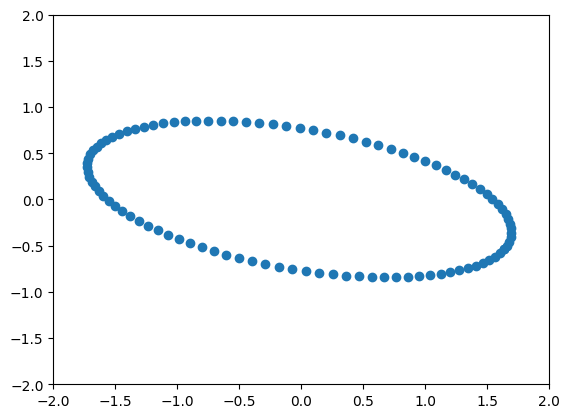

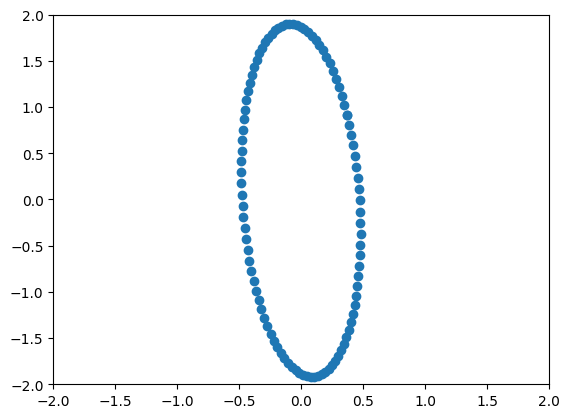

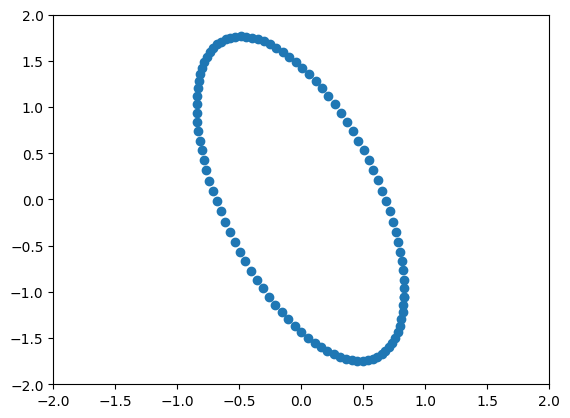

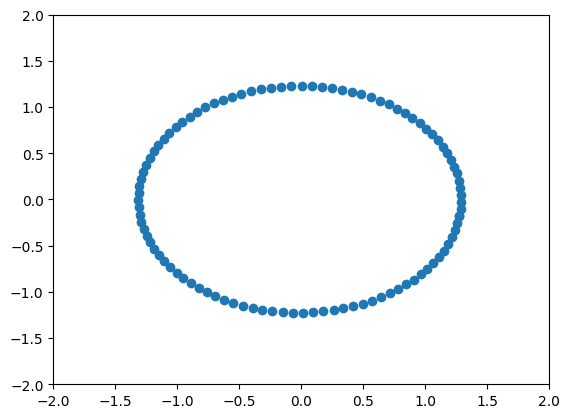

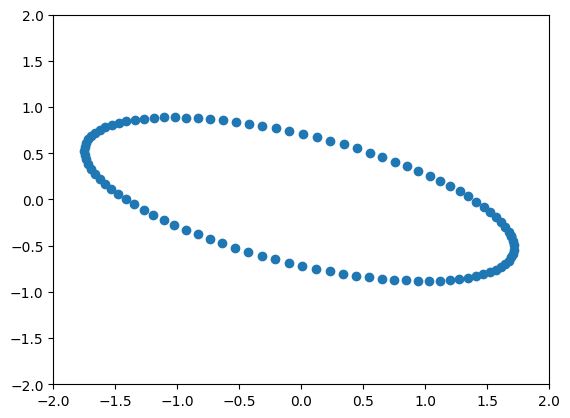

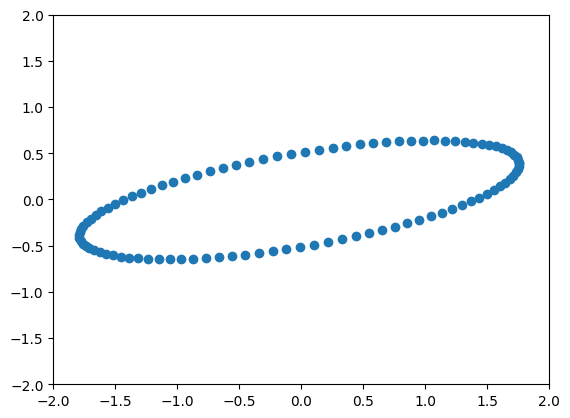

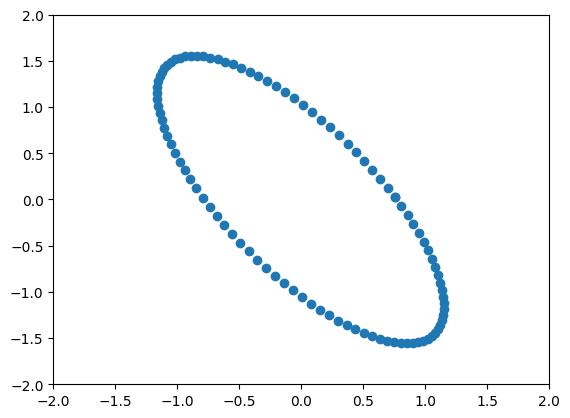

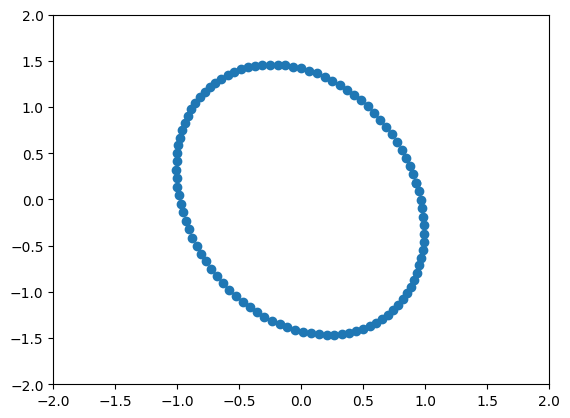

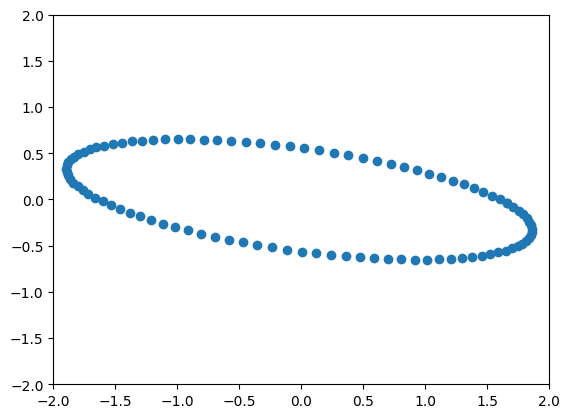

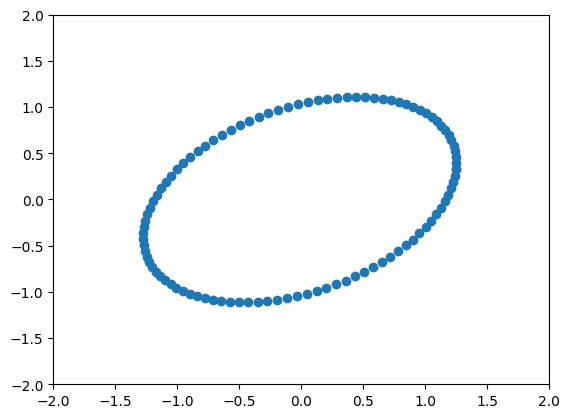

<Figure size 640x480 with 0 Axes>

In [7]:
import matplotlib.pyplot as plt
genae.eval()

for _ in range(10):
    tmp=genae.sample().detach().numpy().reshape(-1,2)
    plt.scatter(tmp[:,0],tmp[:,1])
    plt.xlim(-2, 2)
    plt.ylim(-2,2)
    plt.show()
    plt.clf()



# Whats next?

There are lot of directions to explore:

*   tweak the sinkhorn parameters to study how the affect convergence.
*   changing the latent space dimensionality or the POD dimensionality.
* adopt measures different from sinkhorn for regularizing the latent space.

